In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report


In [4]:
df=pd.read_csv("dataset2.csv")

In [5]:
df

,Message_Length,Num_Links,Num_Uppercase,Num_Special_Chars,Contains_Offer,Contains_Urgent,Spam
0,10,16,39,26,1,1,1
1,177,9,18,29,0,0,0
2,117,9,0,10,0,0,0
3,28,3,4,1,0,0,0
4,341,7,26,29,0,1,1
...,...,...,...,...,...,...,...
495,278,3,39,6,0,1,0
496,30,18,3,3,1,0,0
497,412,5,10,26,1,1,0
498,62,0,30,24,0,0,1


In [6]:
df.head()

,Message_Length,Num_Links,Num_Uppercase,Num_Special_Chars,Contains_Offer,Contains_Urgent,Spam
0,10,16,39,26,1,1,1
1,177,9,18,29,0,0,0
2,117,9,0,10,0,0,0
3,28,3,4,1,0,0,0
4,341,7,26,29,0,1,1


In [7]:
df.describe()

,Message_Length,Num_Links,Num_Uppercase,Num_Special_Chars,Contains_Offer,Contains_Urgent,Spam
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,257.882000,9.622000,24.392000,15.352000,0.494000,0.518000,0.516000
std,141.831408,5.712476,14.934672,8.501803,0.500465,0.500176,0.500244
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,134.000000,5.000000,12.000000,8.000000,0.000000,0.000000,0.000000
50%,259.000000,10.000000,24.000000,15.000000,0.000000,1.000000,1.000000
75%,384.250000,15.000000,38.000000,23.000000,1.000000,1.000000,1.000000
max,498.000000,19.000000,49.000000,29.000000,1.000000,1.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Message_Length     500 non-null    int64
 1   Num_Links          500 non-null    int64
 2   Num_Uppercase      500 non-null    int64
 3   Num_Special_Chars  500 non-null    int64
 4   Contains_Offer     500 non-null    int64
 5   Contains_Urgent    500 non-null    int64
 6   Spam               500 non-null    int64
dtypes: int64(7)
memory usage: 27.5 KB


In [9]:
df.shape

(500, 7)

In [10]:
df.isna().sum()

Message_Length       0
Num_Links            0
Num_Uppercase        0
Num_Special_Chars    0
Contains_Offer       0
Contains_Urgent      0
Spam                 0
dtype: int64

In [11]:
df["Spam"].value_counts()

Spam
1    258
0    242
Name: count, dtype: int64

<Axes: xlabel='Spam', ylabel='count'>

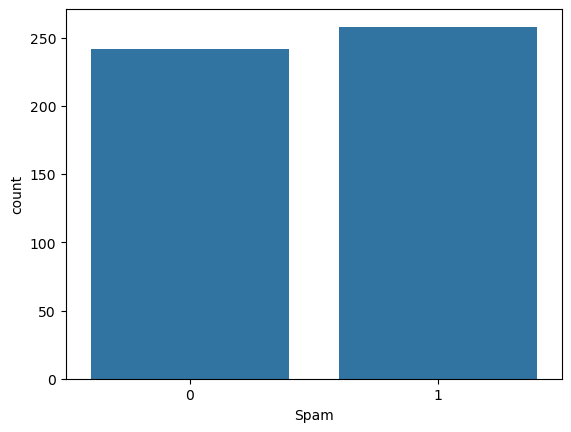

In [12]:
sns.countplot(x="Spam",data=df)


array([[<Axes: title={'center': 'Message_Length'}>,
        <Axes: title={'center': 'Num_Links'}>,
        <Axes: title={'center': 'Num_Uppercase'}>],
       [<Axes: title={'center': 'Num_Special_Chars'}>,
        <Axes: title={'center': 'Contains_Offer'}>,
        <Axes: title={'center': 'Contains_Urgent'}>],
       [<Axes: title={'center': 'Spam'}>, <Axes: >, <Axes: >]],
      dtype=object)

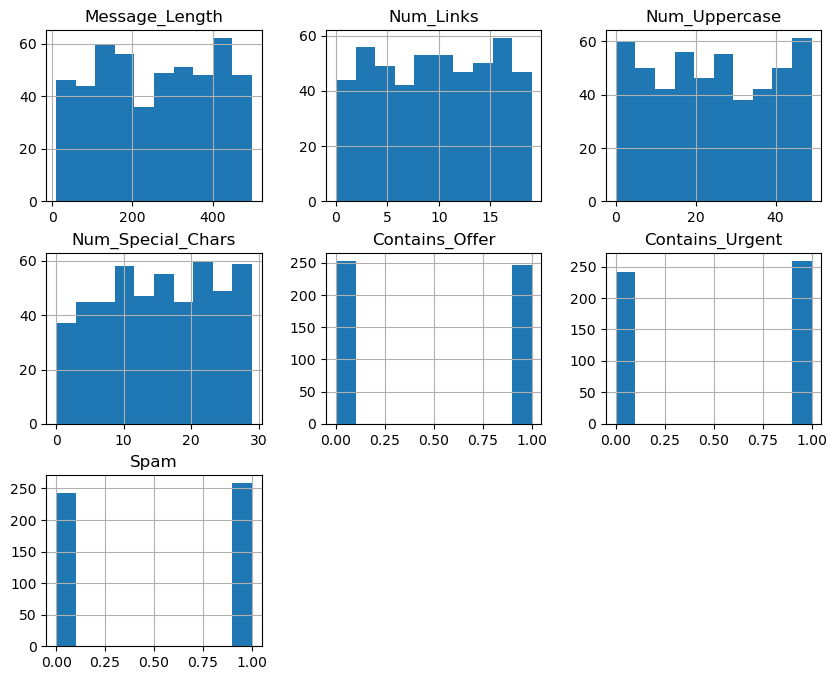

In [13]:
df.hist(figsize=(10,8))

<Axes: >

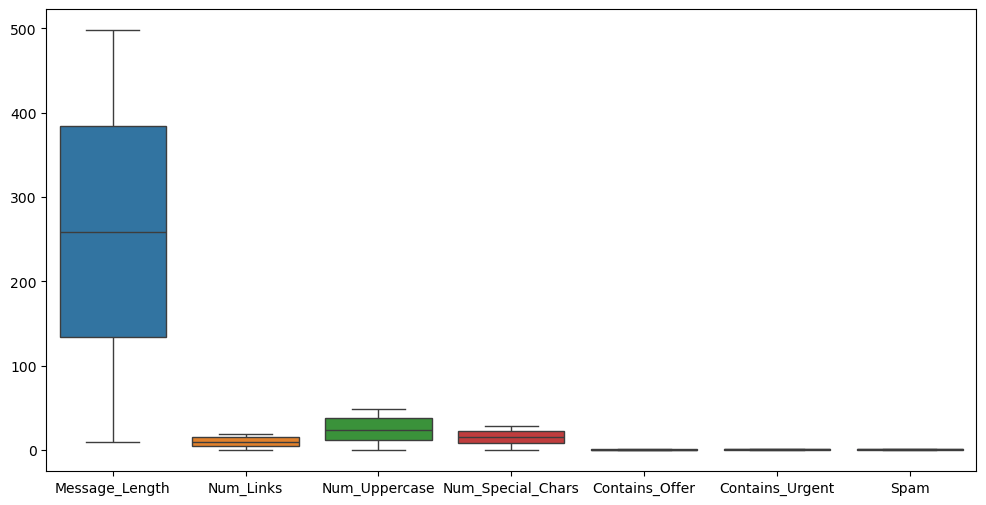

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)


<Axes: >

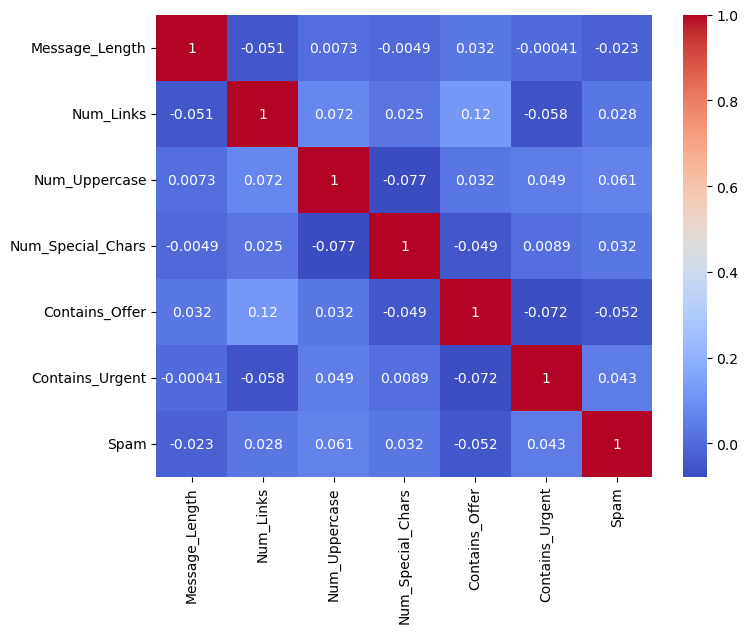

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

In [16]:
df["Offer_Urgent"]=(df["Contains_Offer"]*df["Contains_Urgent"])
df["Links_Length"] = (df["Num_Links"] *df["Message_Length"])
df["Upper_Special"] = (df["Num_Uppercase"] *df["Num_Special_Chars"])

In [17]:
print(df.head())

   Message_Length  Num_Links  Num_Uppercase  Num_Special_Chars  \
0              10         16             39                 26   
1             177          9             18                 29   
2             117          9              0                 10   
3              28          3              4                  1   
4             341          7             26                 29   

   Contains_Offer  Contains_Urgent  Spam  Offer_Urgent  Links_Length  \
0               1                1     1             1           160   
1               0                0     0             0          1593   
2               0                0     0             0          1053   
3               0                0     0             0            84   
4               0                1     1             0          2387   

   Upper_Special  
0           1014  
1            522  
2              0  
3              4  
4            754  


In [18]:
x=df.drop(["Spam"],axis=1)
y=df["Spam"]

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [21]:
lr=LogisticRegression()
lr.fit(x_train_scaled,y_train)
y_pred_lr=lr.predict(x_test_scaled)


In [22]:
accuracy=accuracy_score(y_test,y_pred_lr)
precision=precision_score(y_test,y_pred_lr)
recall=recall_score(y_test,y_pred_lr)
F1=f1_score(y_test,y_pred_lr)

In [23]:
print(accuracy)
print(precision)
print(recall)
print(F1)

0.44
0.4266666666666667
0.7111111111111111
0.5333333333333333


In [24]:
cm=confusion_matrix(y_test,y_pred_lr)
print(cm)


[[12 43]
 [13 32]]


<Axes: >

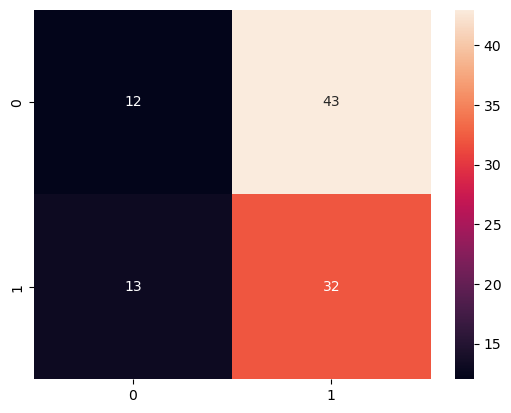

In [25]:
sns.heatmap(cm,annot=True,fmt="d")

In [26]:
nb=GaussianNB()
nb.fit(x_train_scaled,y_train)
y_pred_nb=nb.predict(x_test_scaled)

In [27]:
accuracy=accuracy_score(y_test,y_pred_nb)
precision=precision_score(y_test,y_pred_nb)
recall=recall_score(y_test,y_pred_nb)
F1=f1_score(y_test,y_pred_nb)

In [28]:
print(accuracy)
print(precision)
print(recall)
print(F1)

0.5
0.46153846153846156
0.6666666666666666
0.5454545454545454


In [29]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train_scaled,y_train)
y_pred_rf=rf.predict(x_test_scaled)

In [30]:
accuracy=accuracy_score(y_test,y_pred_rf)
precision=precision_score(y_test,y_pred_rf)
recall=recall_score(y_test,y_pred_rf)
F1=f1_score(y_test,y_pred_rf)

In [31]:
print(accuracy)
print(precision)
print(recall)
print(F1)

0.47
0.4411764705882353
0.6666666666666666
0.5309734513274337


In [32]:
importance=pd.DataFrame(
    {
        'Features':x.columns,
        'Importance':rf.feature_importances_
    }
)

print(importance.sort_values(by="Importance",ascending=False))

            Features  Importance
7       Links_Length    0.186673
0     Message_Length    0.179214
8      Upper_Special    0.171911
2      Num_Uppercase    0.136978
3  Num_Special_Chars    0.136351
1          Num_Links    0.120813
4     Contains_Offer    0.024897
5    Contains_Urgent    0.024002
6       Offer_Urgent    0.019160


In [33]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.53      0.31      0.39        55
           1       0.44      0.67      0.53        45

    accuracy                           0.47       100
   macro avg       0.49      0.49      0.46       100
weighted avg       0.49      0.47      0.45       100



In [34]:
results=pd.DataFrame({
    'Model':['Logistic Regression',
             'Naive Bayes',
             'Random Forest'
            ],
    'Accuracy':
       [
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_nb),
        accuracy_score(y_test,y_pred_rf)
       ],
    'Precision':
       [
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_nb),
        precision_score(y_test,y_pred_rf)
       ],
    'Recall':
       [
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_nb),
        recall_score(y_test,y_pred_rf)
       ],
    'F1':
       [
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_nb),
        f1_score(y_test,y_pred_rf)
       ]
})

print(results)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression      0.44   0.426667  0.711111  0.533333
1          Naive Bayes      0.50   0.461538  0.666667  0.545455
2        Random Forest      0.47   0.441176  0.666667  0.530973


In [39]:
df


,Message_Length,Num_Links,Num_Uppercase,Num_Special_Chars,Contains_Offer,Contains_Urgent,Spam,Offer_Urgent,Links_Length,Upper_Special
0,10,16,39,26,1,1,1,1,160,1014
1,177,9,18,29,0,0,0,0,1593,522
2,117,9,0,10,0,0,0,0,1053,0
3,28,3,4,1,0,0,0,0,84,4
4,341,7,26,29,0,1,1,0,2387,754
...,...,...,...,...,...,...,...,...,...,...
495,278,3,39,6,0,1,0,0,834,234
496,30,18,3,3,1,0,0,0,540,9
497,412,5,10,26,1,1,0,1,2060,260
498,62,0,30,24,0,0,1,0,0,720


In [42]:
new=[[10,16,39,26,1,1,1,0,1]]
prediction=nb.predict(new)
prediction

array([1])